# 02. 군집 수(k) 선정: k=5, 6, 7, 8 비교 → k=8 확정

정량 지표(실루엣 계수, 관성)와 **결과 콘텐츠로서의 해석 가능성**을 함께 놓고 k를 골랐다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import *
setup_plot()
pd.set_option("display.width", 200)
df = load_data()
from sklearn.metrics import silhouette_score
X = df[FEATURES].astype(int)

## 1. PCA 차원 수 × k 별 실루엣 계수

In [2]:
rows = []
for nc in [2, 3, 5]:
    for k in range(3, 11):
        pipe = make_pipeline(k=k, n_components=nc).fit(X)
        P = pipe[:-1].transform(X)
        rows.append({"PCA 차원": nc, "k": k, "silhouette": silhouette_score(P, pipe[-1].labels_)})
sil = pd.DataFrame(rows).pivot(index="k", columns="PCA 차원", values="silhouette").round(3)
sil

PCA 차원,2,3,5
k,,,
3,0.356,0.260,0.161
4,0.353,0.266,0.168
5,0.331,0.259,0.173
6,0.358,0.250,0.166
7,0.339,0.236,0.174
8,0.328,0.236,0.169
9,0.324,0.238,0.166
10,0.326,0.236,0.166


PosixPath('/home/claude/ydplab/analysis/figures/02_silhouette.png')

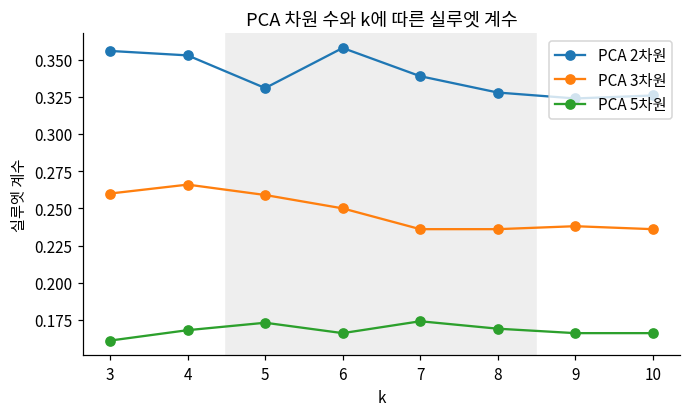

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.8))
for nc in sil.columns:
    ax.plot(sil.index, sil[nc], "o-", label=f"PCA {nc}차원")
ax.axvspan(4.5, 8.5, color="#eee", zorder=0)
ax.set_xlabel("k"); ax.set_ylabel("실루엣 계수"); ax.set_title("PCA 차원 수와 k에 따른 실루엣 계수"); ax.legend()
save(fig, "02_silhouette.png")

PCA 2차원일 때 실루엣이 0.33 ~ 0.36으로 가장 높고, 차원을 늘릴수록 분리도가 떨어진다 → **PCA 2차원 고정**.

## 2. 후보 k=5 ~ 8 비교

In [4]:
cand = []
labels = {}
for k in [5, 6, 7, 8]:
    pipe = make_pipeline(k=k).fit(X)
    P = pipe[:-1].transform(X)
    labels[k] = pipe[-1].labels_
    sizes = np.bincount(labels[k])
    cand.append({"k": k, "silhouette": round(silhouette_score(P, labels[k]), 3),
                 "inertia": round(pipe[-1].inertia_, 1),
                 "최소 군집 크기": sizes.min(), "최대 군집 크기": sizes.max()})
pd.DataFrame(cand).set_index("k")

,silhouette,inertia,최소 군집 크기,최대 군집 크기
k,,,,
5,0.331,2563.6,383,692
6,0.358,2082.5,306,522
7,0.339,1833.2,236,493
8,0.328,1645.5,220,443


PosixPath('/home/claude/ydplab/analysis/figures/02_k_compare.png')

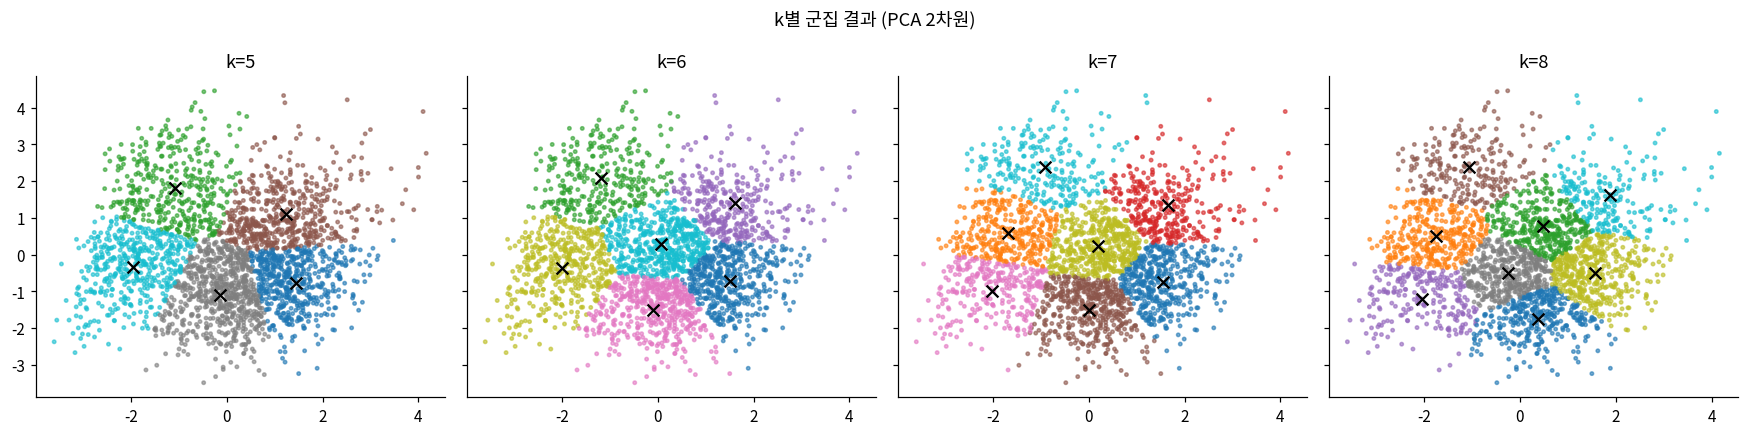

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
for ax, k in zip(axes, [5, 6, 7, 8]):
    pipe = make_pipeline(k=k).fit(X)
    P = pipe[:-1].transform(X)
    ax.scatter(P[:, 0], P[:, 1], c=labels[k], cmap="tab10", s=5, alpha=.6)
    c = pipe[-1].cluster_centers_
    ax.scatter(c[:, 0], c[:, 1], c="black", marker="x", s=60)
    ax.set_title(f"k={k}")
fig.suptitle("k별 군집 결과 (PCA 2차원)"); fig.tight_layout()
save(fig, "02_k_compare.png")

## 3. k=8에서만 갈라지는 군집 확인

In [6]:
prof = df.assign(k6=labels[6], k8=labels[8])
pd.crosstab(prof["k8"].map(lambda c: f"{c} {ANIMALS[c]}"), prof["k6"], margins=True)

k6,0,1,2,3,4,5,All
k8,,,,,,,
0 범고래,69,0,0,294,0,0,363
1 왜가리,0,69,0,0,228,41,338
2 매너티,1,17,93,0,0,261,372
3 알바트로스,0,0,0,44,196,0,240
4 푸른바다거북,0,220,3,0,0,0,223
5 돌고래,4,0,0,162,29,206,401
6 펭귄,402,0,27,0,0,14,443
7 해파리,0,0,220,0,0,0,220
All,476,306,343,500,453,522,2600


In [7]:
g = df.assign(c=labels[8]).groupby("c")[RATIO_COLS].mean().round(1)
g.index = [f"{c} {ANIMALS[c]}" for c in g.index]
g.columns = [FEATURE_KO[c] for c in g.columns]
g["인원"] = np.bincount(labels[8])
g

,평일 여가시간,주말 여가시간,휴식·오락 비율,취미 비율,자기계발 비율,대인관계 비율,인원
0 범고래,2.6,4.8,16.8,33.4,21.4,27.0,363
1 왜가리,2.6,4.9,40.4,16.2,12.3,27.1,338
2 매너티,3.6,6.9,57.2,11.3,9.1,20.4,372
3 알바트로스,2.1,3.6,13.3,40.8,17.8,25.1,240
4 푸른바다거북,3.5,6.4,83.6,4.0,3.4,8.3,223
5 돌고래,2.8,5.5,32.0,22.1,14.8,27.3,401
6 펭귄,3.6,6.9,39.4,15.1,15.3,27.4,443
7 해파리,5.5,9.1,75.9,4.7,5.1,12.8,220


## 결론: k=8

| 기준 | 판단 |
|---|---|
| 실루엣 계수 | k=5 ~ 8 모두 0.33 ~ 0.36 범위로 큰 차이가 없음 → 정량 지표만으로는 결정할 수 없음 |
| 군집 크기 | k=8에서도 가장 작은 군집이 220명(8.5%) 이상 → 너무 작은 군집이 생기지 않음 |
| 해석 가능성 | k=6 → k=8로 늘리면 (1) 돌고래와 섞여 있던 **매너티(휴식형)**, (2) 왜가리·범고래와 섞여 있던 **알바트로스(여가 최소·취미 최대)**, (3) 매너티 일부와 묶여 있던 **해파리(여가시간 최대)**가 독립된다(위 교차표). 반면 푸른바다거북은 k=6에서도 거의 그대로 유지된다 → 늘어난 군집이 모두 해석 가능한 새 유형 |
| 서비스 목적 | 부스 체험형 테스트에서 8개 유형은 결과가 겹치지 않으면서 친구끼리 비교하는 재미를 줄 수 있는 수 |

> 실루엣이 비슷한 구간에서는 **도메인 해석과 서비스 목적**으로 k를 결정했다. 03 노트북에서 각 군집이 실제로 구별되는 특성을 갖는지 검증한다.